In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

In [14]:
housing = fetch_california_housing()

X = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

y = housing.target

print("Dataset Shape:", X.shape)

X.head()

Dataset Shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (16512, 8)
Testing Shape: (4128, 8)


In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
linear = LinearRegression()

linear.fit(X_train, y_train)

linear_pred = linear.predict(X_test)

print("Linear Regression")

print("R2 Score:", r2_score(y_test, linear_pred))

print("MSE:", mean_squared_error(y_test, linear_pred))

Linear Regression
R2 Score: 0.575787706032451
MSE: 0.5558915986952442


In [18]:
ridge = Ridge(alpha=1)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge Regression")

print("R2 Score:", r2_score(y_test, ridge_pred))

print("MSE:", mean_squared_error(y_test, ridge_pred))

Ridge Regression
R2 Score: 0.5758157428913684
MSE: 0.5558548589435971


In [19]:
lasso = Lasso(alpha=0.01)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso Regression")

print("R2 Score:", r2_score(y_test, lasso_pred))

print("MSE:", mean_squared_error(y_test, lasso_pred))

Lasso Regression
R2 Score: 0.5816154300698727
MSE: 0.5482548967938964


In [20]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge",
        "Lasso"
    ],

    "R2 Score":[

        r2_score(y_test, linear_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)

    ],

    "MSE":[

        mean_squared_error(y_test, linear_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred)

    ]

})

comparison

,Model,R2 Score,MSE
0,Linear Regression,0.575788,0.555892
1,Ridge,0.575816,0.555855
2,Lasso,0.581615,0.548255


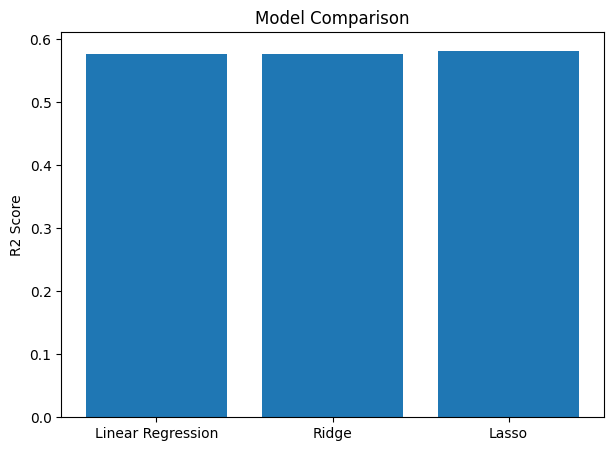

In [21]:
plt.figure(figsize=(7,5))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"]
)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.show()

In [22]:
parameters = {

    "alpha":[0.001,0.01,0.1,1,10,100]

}

grid = GridSearchCV(

    estimator=Ridge(),

    param_grid=parameters,

    cv=5,

    scoring="r2"

)

grid.fit(X_train,y_train)

print("Best Alpha:",grid.best_params_)

print("Best CV Score:",grid.best_score_)

Best Alpha: {'alpha': 0.001}
Best CV Score: 0.6114839952527685


In [23]:
random = RandomizedSearchCV(

    estimator=Ridge(),

    param_distributions=parameters,

    n_iter=5,

    cv=5,

    random_state=42,

    scoring="r2"

)

random.fit(X_train,y_train)

print("Random Search Best Alpha")

print(random.best_params_)

print(random.best_score_)

Random Search Best Alpha
{'alpha': 0.001}
0.6114839952527685


In [24]:
best_model = grid.best_estimator_

prediction = best_model.predict(X_test)

print("Best Model Test R2")

print(r2_score(y_test,prediction))

Best Model Test R2
0.5757877341612514


In [25]:
coef = pd.DataFrame({

    "Feature":housing.feature_names,

    "Coefficient":best_model.coef_

})

coef

,Feature,Coefficient
0,MedInc,0.854383
1,HouseAge,0.122546
2,AveRooms,-0.294410
3,AveBedrms,0.339259
4,Population,-0.002308
5,AveOccup,-0.040829
6,Latitude,-0.896928
7,Longitude,-0.869841


In [26]:
print("Bias-Variance Tradeoff")

print()

print("High Bias -> Underfitting")

print("High Variance -> Overfitting")

print("Regularization reduces overfitting.")

print("Grid Search systematically searches every parameter.")

print("Randomized Search searches randomly and is faster.")

Bias-Variance Tradeoff

High Bias -> Underfitting
High Variance -> Overfitting
Regularization reduces overfitting.
Grid Search systematically searches every parameter.
Randomized Search searches randomly and is faster.


In [27]:
checklist = [

"Dataset Loaded",

"Train Test Split Completed",

"Scaling Applied",

"Linear Regression Completed",

"Ridge Completed",

"Lasso Completed",

"Grid Search Completed",

"Randomized Search Completed",

"Comparison Chart Created"

]

for item in checklist:

    print("✔",item)

✔ Dataset Loaded
✔ Train Test Split Completed
✔ Scaling Applied
✔ Linear Regression Completed
✔ Ridge Completed
✔ Lasso Completed
✔ Grid Search Completed
✔ Randomized Search Completed
✔ Comparison Chart Created


In [28]:
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression

def practice(alpha):
    X, y = make_regression(
        n_samples=100,
        n_features=5,
        noise=10,
        random_state=42
    )

    model = Ridge(alpha=alpha)
    model.fit(X, y)

    score = model.score(X, y)

    print(f"Alpha: {alpha}")
    print(f"R² Score: {score:.4f}")
    print("-" * 30)

# Test with 3 different inputs
practice(0.1)
practice(1)
practice(10)

print("Done! Review with CIA for feedback.")

Alpha: 0.1
R² Score: 0.9955
------------------------------
Alpha: 1
R² Score: 0.9954
------------------------------
Alpha: 10
R² Score: 0.9850
------------------------------
Done! Review with CIA for feedback.
